In [1]:
import sys
from pyprojroot import here

sys.path.insert(0, str(here()))

import pandas as pd
import numpy as np
import xarray as xr

import pymc as pm
import pytensor.tensor as pt
import pymc_extras as pmx
import matplotlib.pyplot as plt
import arviz as az

from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve

from libpysal.weights import KNN, fuzzy_contiguity, w_union, W
import networkx as nx
import warnings

config = {
    'figure.figsize':(14,4),
    'figure.constrained_layout.use':True,
    'figure.facecolor':'w',
    'axes.grid':False,
    'grid.linewidth':0.5,
    'grid.linestyle':'--',
    'axes.spines.top':False,
    'axes.spines.bottom':False,
    'axes.spines.left':False,
    'axes.spines.right':False
}

plt.rcParams.update(config)

SEED = sum(list(map(ord, 'climate_bayes')))
rng = np.random.default_rng(SEED)

In [2]:
from laos_gggi import load_shapefile
from laos_gggi.replication_data import create_replication_data
from laos_gggi.data_functions import load_emdat_data, load_all_data
from laos_gggi.sample import sample_or_load

In [3]:
df = (create_replication_data()
        .rename(columns={'ISO':'iso'})
        .set_index(["iso", "year"]))

In [4]:
#Load shapefiles
world = (load_shapefile('world', repair_ISO_codes=True)
            .rename(columns={'ISO_A3':'iso'})
            .set_index('iso'))
laos = load_shapefile('laos')

# Data loading and preparation

In [5]:
df = (create_replication_data()
        .rename(columns={'ISO':'iso'})
        .set_index(["iso", "year"]))

In [6]:
#Load shapefiles
world = (load_shapefile('world', repair_ISO_codes=True)
            .rename(columns={'ISO_A3':'iso'})
            .set_index('iso'))
laos = load_shapefile('laos')

## Dropping row missing covariates

There are years for which we don't have covariate data; these have to be dropped. We can keep missing damage and event data. These are probably zero, but maybe not. The pattern of missingness isn't random.

In [7]:
disasters = ["climatological_disasters", "hydrological_disasters"]
effects = ['Total_Damage_Adjusted_hydro', 'Total_Damage_Adjusted_clim']
features = ["ln_population_density", 
            "ln_gdp_pc", 
            "square_ln_gdp_p", 
            "precip_deviation", 
            "co2", 
            "population"]

In [8]:
df.dropna(subset=features, inplace=True)

## Reconcile EMDAT and shapefile ISO codes

In [9]:
df_iso = df.index.get_level_values('iso').unique()
world_iso = world.index.unique()

In [10]:
# Codes in EMDAT but not in world
", ".join(list(set(df_iso) - set(world_iso)))

''

In [11]:
# Codes in shapefile but not in EMDAT
", ".join(list(set(world_iso) - set(df_iso)))

'CYM, MAF, MDV, NIU, KNA, JAM, GRL, ABW, GUM, HMD, LUX, VGB, BRB, GIB, KIR, MLT, VIR, SPM, COK, BLM, LCA, SHN, ATG, BMU, CPV, FLK, QAT, MSR, BHR, BHS, MHL, PRI, GGY, NRU, DMA, MCO, TTO, TON, SMR, TUV, ATF, CUW, SXM, NFK, ASM, GRD, MNP, PCN, HKG, COM, STP, SGP, ISR, FRO, PSE, AIA, WLF, PRK, SLB, TCA, VCT, SGS, MAC, CYP, VAT, AND, JEY, SYC, FSM, LIE, IMN, PLW, VEN, UNK, IOT'

# Damage from Event Model

In [12]:
def ppc_plot(iso, classes, 
             idata=None,
             predictions=None,
             group='posterior', 
             target='y_hat',
             hdi_lim=1.0):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    
    if idata is None and predictions is None:
        raise ValueError('Need at least one of idata or predictions')
    
    for cls, axis in zip(classes, fig.axes):
        sel = {'obs_iso': iso, 'obs_disaster_class':cls}

        if predictions is None:
            pp = idata[f'{group}_predictive'].sel(obs_iso = iso)
        else:
            pp = predictions['predictions'].sel(obs_iso = iso)
        
        if cls not in pp.coords['obs_disaster_class']:
            axis.set_title(cls)
            continue
        else:
            pp = pp.sel(obs_disaster_class = cls)
        
        if idata is not None:
            obs = idata.observed_data.sel(obs_iso = iso)
            observed = True
        if cls not in obs.coords['obs_disaster_class']:
            obs = pp.copy().mean(dim=['chain', 'draw']) # Dummy data, otherwise plot_ppc throws a fit
            observed=False
        else:
            obs = obs.sel(obs_disaster_class = cls)
        
        pp[target] = pp[target] + np.random.uniform(0, 1e-6, size=pp[target].values.shape)
        
        az.plot_ppc(az.InferenceData(posterior_predictive=pp,
                                     observed_data=obs),
                    ax=axis,
                    var_names=target,
                    observed=observed,
                    legend=False)
            
        axis.set_title(cls)
        
        if hdi_lim < 1.0:
            hdi = az.hdi(pp, hdi_prob=hdi_lim)[target]
            higher = hdi.sel(hdi = 'higher').max()
            axis.set_xlim(0, higher)
            
            
def damage_plot(iso, idata, df, cls='hydro', group='posterior_predictive'):
    fig, ax = plt.subplots()
    data = idata[group].y_hat.sel(obs_iso=iso, obs_disaster_class=cls).groupby('obs_year').mean()
    targets = df.query('iso == @iso & disaster_class == @cls').groupby('year')['Total_Damage_Adjusted'].mean().resample('YS').last()

    mu = data.quantile(0.5, dim=['chain', 'draw']).to_dataframe()['y_hat'].resample('YS').last()

    hdi_80 = az.hdi(data, hdi_prob=0.8).y_hat.to_dataframe()['y_hat'].unstack('hdi').resample('YS').last()
    hdi_94 = az.hdi(data).y_hat.to_dataframe()['y_hat'].unstack('hdi').resample('YS').last()

    ax.scatter(targets.index, targets.values, color='tab:red', zorder=100)
    ax.scatter(mu.index, mu.values, s=70)

    ax.vlines(mu.index, *hdi_80.values.T, lw=3)
    ax.vlines(mu.index, *hdi_94.values.T)
    ax.grid(ls='--', lw=0.5)
    # ax.set(title = f'{iso} - {cls}')
    plt.show()
            

# More Data

In [13]:
emdat = load_emdat_data()

In [14]:
damage_events = (emdat['df_raw_filtered_adj']
           .loc[:, ['Start_Year', 'ISO', 'disaster_class', 'Total_Damage_Adjusted']]
           .dropna()
           .reset_index(drop=True)
           .rename(columns={'Start_Year':'year', 'ISO':'iso'})
                .replace({'Climatological':'climate',
                         'Hydrometereological':'hydro'}))

In [15]:
damage_events_full = (damage_events
     .groupby(['iso', 'year', 'disaster_class'])
     .apply(lambda x: x.assign(idx = np.arange(x.shape[0])), 
            include_groups=False)
     .reset_index()
     .set_index(['iso', 'year', 'disaster_class', 'idx']))

# Get unique iso codes and years
_, codes = pd.factorize(damage_events_full.index.get_level_values(0), sort=True)
_, years = pd.factorize(damage_events_full.index.get_level_values(1), sort=True)
_, classes = pd.factorize(damage_events_full.index.get_level_values(2))

power_set = pd.MultiIndex.from_product([codes, years, classes, [0]], names=['iso', 'year', 'disaster_class', 'idx'])
total = pd.MultiIndex.from_tuples(set(power_set.values).union(set(damage_events_full.index)), names=['iso', 'year', 'disaster_class', 'idx'])

damage_events_full = damage_events_full.reindex(total).sort_index().drop(columns=['level_3'])
df_damage_full = (pd.merge(damage_events_full.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage_full['Total_Damage_Adjusted'] = df_damage_full['Total_Damage_Adjusted'] / 1e3

In [16]:
df_damage = (pd.merge(damage_events.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage['Total_Damage_Adjusted'] = df_damage['Total_Damage_Adjusted'] / 1e3

In [17]:
df_damage_full = df_damage_full.query('iso in @df_damage.iso').copy()

In [18]:
# **IMPORTANT**
# Factorize with respect to df, because that's the dataset used in the frequency model
# this way everything agrees. There will end up being countries for which there is no data,
# but that's fine.
_, codes = pd.factorize(df.index.get_level_values("iso"), sort=True)
_, years = pd.factorize(df.index.get_level_values("year"), sort=True)
class_idx, classes = pd.factorize(df_damage['disaster_class'])

iso_to_idx = {code: idx for idx, code in enumerate(codes)}
year_to_idx = {year: idx for idx, year in enumerate(years)}
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

iso_idx = np.array(list(map(iso_to_idx.get, df_damage.iso)))
year_idx = np.array(list(map(year_to_idx.get, df_damage.year)))


In [19]:
iso_idx_oos = np.array(list(map(iso_to_idx.get, df_damage_full.iso)))
year_idx_oos = np.array(list(map(year_to_idx.get, df_damage_full.year)))
class_idx_oos = np.array(list(map(class_to_idx.get, df_damage_full.disaster_class)))
                  
idx_cols = ["iso", "year", "disaster_class"]
rename_dict = {col: f'obs_{col}' for col in idx_cols}

idx = (xr.Coordinates
           .from_pandas_multiindex(df_damage.set_index(idx_cols).index.rename(rename_dict) , 
                                   dim = "obs_idx"))
idx_oos =(xr.Coordinates
           .from_pandas_multiindex(df_damage_full.set_index(idx_cols).index.rename(rename_dict) , 
                                   dim = "obs_idx"))

# Dumb Model

In [20]:
dmg_results = {}

coords = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': classes,
    'obs_idx': np.arange(df_damage.shape[0])
}

with pm.Model(coords=coords, check_bounds=False) as dmg_model0:
    iso_idx_pt = pm.Data('iso_idx', iso_idx, dims=['obs_idx'])
    year_idx_pt = pm.Data('year_idx', year_idx, dims=['obs_idx'])
    class_idx_pt = pm.Data('class_idx', class_idx, dims=['obs_idx'])
    
    intercept = pm.Normal('intercept', 0, 1, dims=['disaster'])
    year_effect = pm.Normal('year_effect', 0, 1, dims=['year', 'disaster'])
    country_effect = pm.ZeroSumNormal('country_effect', 1, dims=['iso', 'disaster'])
    
    mu = intercept + year_effect[year_idx_pt] + country_effect[iso_idx_pt]
    sigma = pm.Gamma('sigma', alpha=2, beta=100, dims=['disaster'])
    
    mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]
    mu = pm.Deterministic('mu', pt.concatenate(mus, axis=0), dims=['obs_idx'])
    
    p_zero = pm.Beta('p_zero', 1, 20, dims=['disaster'])
    y_hat = pm.HurdleLogNormal('y_hat',
                               mu=mu,
                               sigma=sigma[class_idx_pt],
                               psi=(1 - p_zero)[class_idx_pt],
                               observed=df_damage['Total_Damage_Adjusted'],
                               dims=['obs_idx'])
    
    prior = pm.sample_prior_predictive(compile_kwargs={'mode':'FAST_RUN'}).assign_coords(idx)

ppc_plot('USA', classes, prior, group='prior')

dmg_results = {}
with dmg_model0:
    idata = sample_or_load(fp='idata/dmg_model_0.nc',
                           sample_kwargs=dict(
                               nuts_sampler='pymc',
                               init='advi+adapt_diag',
                               cores=8,
                               chains=8, 
                               draws=500,
                               compile_kwargs={'mode':'NUMBA'},
                               ),
                           compile_kwargs={'mode':'NUMBA'},
                           force_resample=False,
                           save_results=True
                          )
    idata = idata.assign_coords(idx)
    
    pm.set_data({
        'iso_idx': iso_idx_oos, 
        'year_idx': year_idx_oos, 
        'class_idx': class_idx_oos,
        },
    coords={'obs_idx':np.arange(df_damage_full.shape[0])})
    idata_oos = (pm.sample_posterior_predictive(idata, predictions=True, extend_inferencedata=False,
                                               compile_kwargs={'mode':"NUMBA"})
                 .assign_coords(idx_oos))
    
    dmg_results['model0'] = idata

az.summary(idata, var_names=['intercept', 'p_zero', 'sigma'])

fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['country_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['year_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Time Effect")

ppc_plot('LAO', classes, idata, predictions=idata_oos, hdi_lim=0.90)

damage_plot('LAO', idata_oos, df_damage, group='predictions', cls='climate')

damage_plot('LAO', idata_oos, df_damage, group='predictions')

# Hierarchical Dumb Model

coords = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': classes,
    'obs_idx': np.arange(df_damage.shape[0])
}

with pm.Model(coords=coords, check_bounds=False) as dmg_model1:
    iso_idx_pt = pm.Data('iso_idx', iso_idx, dims=['obs_idx'])
    year_idx_pt = pm.Data('year_idx', year_idx, dims=['obs_idx'])
    class_idx_pt = pm.Data('class_idx', class_idx, dims=['obs_idx'])
        
        
    year_loc = pm.Normal('year_loc', 0, 1, dims=['disaster'])
    year_scale = pm.Gamma('year_scale', alpha=2, beta=1, dims=['disaster'])
    year_offset = pm.Normal('year_offset', 0, 1, dims=['year', 'disaster'])
    year_effect = pm.Deterministic('year_effect', 
                                   year_loc[None] + year_scale[None] * year_offset, 
                                   dims=['year', 'disaster'])
    
    
    country_loc = pm.Normal('country_loc', 0, 1, dims=['disaster'])
    country_scale = pm.Gamma('country_scale', alpha=2, beta=1, dims=['disaster'])
    country_offset = pm.ZeroSumNormal('country_offset', 1, dims=['iso', 'disaster'])
    country_effect = pm.Deterministic('country_effect', 
                                   country_loc[None] + country_scale[None] * country_offset, 
                                   dims=['iso', 'disaster'])
    
    
    
    mu = year_effect[year_idx_pt] + country_effect[iso_idx_pt]
    sigma = pm.Gamma('sigma', alpha=2, beta=1, dims=['disaster'])
    
    mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]

    mu = pm.Deterministic('mu', pt.concatenate(mus, axis=0), dims=['obs_idx'])
            
    p_zero = pm.Beta('p_zero', 3, 1, dims=['disaster'])
    y_hat = pm.HurdleLogNormal('y_hat',
                           mu=mu,
                           sigma=sigma[class_idx_pt],
                           psi=(1 - p_zero)[class_idx_pt],
                           observed=df_damage['Total_Damage_Adjusted'],
                           dims=['obs_idx'])
    
    prior = pm.sample_prior_predictive(compile_kwargs={'mode':'FAST_RUN'}).assign_coords(idx)

with dmg_model1:
    idata = sample_or_load(fp='idata/dmg_model_1.nc',
                           sample_kwargs=dict(
                               init='advi+adapt_diag',
                               cores=8,
                               chains=8, 
                               draws=500,
                               compile_kwargs={'mode':'NUMBA'},
                               ),
                           compile_kwargs={'mode':'NUMBA'},
                           force_resample=False,
                           save_results=True
                          )
    idata = idata.assign_coords(idx)
    
    pm.set_data({
        'iso_idx': iso_idx_oos, 
        'year_idx': year_idx_oos, 
        'class_idx': class_idx_oos,
        },
    coords={'obs_idx':np.arange(df_damage_full.shape[0])})
    idata_oos = (pm.sample_posterior_predictive(idata, predictions=True, extend_inferencedata=False,
                                               compile_kwargs={'mode':"NUMBA"})
                 .assign_coords(idx_oos))
    
    dmg_results['model1'] = idata

fig = az.plot_ppc(idata, 
                  var_names=['y_hat'], 
                  flatten=['chain', 'draw', 'obs_idx'])
fig.set_xlim(0, 25)
plt.show()

ppc_plot('LAO', classes, idata, predictions=idata_oos, hdi_lim=0.90)

az.summary(idata, var_names=['_loc', '_scale', 'p_zero'], filter_vars='like')

fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['country_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['year_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Time Effect")

ppc_plot('LAO', classes, idata, predictions=idata_oos, hdi_lim=0.90)

damage_plot('LAO', idata_oos, df_damage, group='predictions', cls='climate')

damage_plot('LAO', idata_oos, df_damage, group='predictions')

# Covariates Only Model

In [21]:
X_damage = df_damage[features]
X_damage_full = df_damage_full[features]

In [22]:
def standardize(x):
    return (x - x.mean()) / x.std()

coords = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': classes,
    'obs_idx': np.arange(df_damage.shape[0]),
    'feature': features
}

with pm.Model(coords=coords, check_bounds=False) as dmg_model2:
    class_idx_pt = pm.Data('class_idx', class_idx, dims=['obs_idx'])
    X = pm.Data('X', 
                X_damage.transform(standardize).eval('square_ln_gdp_p = ln_gdp_pc ** 2'), 
                dims=['obs_idx', 'feature'])
    
    intercept = pm.Laplace('intercept', 0, 1, dims=['disaster'])
    
    beta = pm.Laplace('beta', 0, 0.5, dims=['feature', 'disaster'])
    coef_effect = X @ beta
    
    mu = intercept + coef_effect    
    sigma = pm.Exponential('sigma', 10, dims=['disaster'])
    
    mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]
    mu = pm.Deterministic('mu', pt.concatenate(mus, axis=0), dims=['obs_idx'])
    
    p_zero = pm.Beta('p_zero', 3, 1, dims=['disaster'])
    
    y_hat = pm.HurdleLogNormal('y_hat',
                           mu=mu,
                           sigma=sigma[class_idx_pt],
                           psi=(1 - p_zero)[class_idx_pt],
                           observed=df_damage['Total_Damage_Adjusted'],
                           dims=['obs_idx'])
    
    prior = pm.sample_prior_predictive().assign_coords(idx)

ppc_plot('LAO', classes, idata=prior, group='prior')

with dmg_model2:
    idata = sample_or_load(fp='idata/dmg_model_2.nc',
                           sample_kwargs=dict(
                               # nuts_sampler='pymc',
                               # init='advi+adapt_diag',
                               cores=8,
                               chains=8, 
                               draws=500,
                               # compile_kwargs={'mode':'NUMBA'}
#                                nuts_sampler_kwargs={'backend':'jax'}
                               ),
                           compile_kwargs={'mode':'NUMBA'},
                           force_resample=False,
                           save_results=True
                          )
    idata = idata.assign_coords(idx)
    pm.set_data({
#         'iso_idx': iso_idx_oos, 
#         'year_idx': year_idx_oos, 
        'class_idx': class_idx_oos,
        'X':X_damage_full.transform(standardize).eval('square_ln_gdp_p = ln_gdp_pc ** 2')
        },
    coords={'obs_idx':np.arange(df_damage_full.shape[0])})
    idata_oos = (pm.sample_posterior_predictive(idata, predictions=True, extend_inferencedata=False,
                                               compile_kwargs={'mode':"NUMBA"})
                 .assign_coords(idx_oos))
    dmg_results['model2'] = idata

fig = az.plot_ppc(idata, 
                  var_names=['y_hat'], 
                  flatten=['chain', 'draw', 'obs_idx'])
fig.set_xlim(0, 25)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['beta'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=12)
    axis.set_title(disaster.title() + " Disasters, Feature Betas")

ppc_plot('LAO', classes, idata=idata, predictions=idata_oos, hdi_lim=0.9)

damage_plot('LAO', idata_oos, df_damage, group='predictions', cls='climate')

damage_plot('LAO', idata_oos, df_damage, group='predictions')

# Covariates + Panel 

In [23]:
national_features = list(filter(lambda x: x != 'co2', features))
world_features = ['co2']

In [24]:
coords = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': classes,
    'obs_idx': np.arange(df_damage.shape[0]),
    'feature': features,
    'national_feature': national_features,
    'world_feature': world_features,
    'fixed_effect': ['iso', 'year']
}

with pm.Model(coords=coords, check_bounds=False) as dmg_model3:
    X = pm.Data('X', 
                X_damage.transform(standardize).eval('square_ln_gdp_p = ln_gdp_pc ** 2'), 
                dims=['obs_idx', 'feature'])
    
    co2_idx = features.index('co2')
    not_co2_idx = [i for i in range(len(features)) if i != co2_idx]
    
    iso_idx_pt = pm.Data('iso_idx', iso_idx, dims=['obs_idx'])
    year_idx_pt = pm.Data('year_idx', year_idx, dims=['obs_idx'])
    class_idx_pt = pm.Data('class_idx', class_idx, dims=['obs_idx'])

    # Mundlak Adjustment
    beta_GX = pm.Normal('beta_GX', 0, 1, dims=['fixed_effect', 'feature'])
    
    latent_iso = pm.ZeroSumNormal('latent_iso', 3, dims=['iso', 'feature'])
    
    # The within-country variance of co2 is zero, because all countries have the same values of co2
    # So the latent effect needs to be constrained to zero (otherwise it doesn't sample)
    latent_year_national = pm.ZeroSumNormal('latent_year_national', 3, dims=['year', 'national_feature'])
    latent_year = pt.zeros((len(years), len(features)))[:, not_co2_idx].set(latent_year_national)
    
    alpha_X = pm.Normal('alpha_X', 0, 1, dims=['feature'])
    sigma_X = pm.Exponential('sigma_X', 1, dims=['feature'])
        
    mu_X = alpha_X + (beta_GX[0] * latent_iso)[iso_idx_pt] + (beta_GX[1] * latent_year)[year_idx_pt]
    X_hat = pm.Normal('X_hat', 
                      mu=mu_X, 
                      sigma=sigma_X,
                      observed=X, 
                      dims=['obs_idx', 'feature'])
    
    country_loc = pm.Normal('country_loc', 0, 1, dims=['disaster'])
    country_scale = pm.Gamma('country_scale', alpha=2, beta=10, dims=['disaster'])
    country_offset = pm.ZeroSumNormal('country_offset', 1, dims=['iso', 'disaster'])
    country_effect = pm.Deterministic('country_effect', country_loc + country_scale * country_offset,
                                      dims=['iso', 'disaster'])
            
    year_loc = pm.Normal('year_loc', 0, 1, dims=['disaster'])
    year_scale = pm.Gamma('year_scale', alpha=2, beta=1, dims=['disaster'])
    year_offset = pm.Normal('year_offset', 0, 1, dims=['year', 'disaster'])
    year_effect = pm.Deterministic('year_effect', 
                                   year_loc[None] + year_scale[None] * year_offset, 
                                   dims=['year', 'disaster'])
    
    beta = pm.Laplace('beta', 0, 0.5, dims=['feature', 'disaster'])
    beta_GY = pm.Normal('beta_GY', 0, 0.5, dims=['fixed_effect', 'feature', 'disaster'])    
    coef_effect = (X @ beta + 
                   (latent_iso @ beta_GY[0])[iso_idx_pt] + 
                   (latent_year @ beta_GY[1])[year_idx_pt] 
                  )
    mu = country_effect[iso_idx_pt] + year_effect[year_idx_pt] + coef_effect

    sigma = pm.Exponential('sigma', 10, dims=['disaster'])
    
    mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]
    mu = pm.Deterministic('mu', pt.concatenate(mus, axis=0), dims=['obs_idx'])
    
    p_zero = pm.Beta('p_zero', 3, 1, dims=['disaster'])
    y_hat = pm.HurdleLogNormal('y_hat',
                       mu=mu,
                       sigma=sigma[class_idx_pt],
                       psi=(1 - p_zero)[class_idx_pt],
                       observed=df_damage['Total_Damage_Adjusted'],
                       dims=['obs_idx'])

    prior = pm.sample_prior_predictive().assign_coords(idx)

Sampling: [X_hat, alpha_X, beta, beta_GX, beta_GY, country_loc, country_offset, country_scale, latent_iso, latent_year_national, p_zero, sigma, sigma_X, y_hat, year_loc, year_offset, year_scale]


ppc_plot('USA', classes, idata=prior, group='prior')

In [25]:
with dmg_model3:
    idata = sample_or_load(fp='idata/dmg_model_3.nc',
                           sample_kwargs=dict(
                               # nuts_sampler='pymc',
                               # init='advi+adapt_diag',
                               cores=8,
                               chains=8, 
                               draws=500,
                               # compile_kwargs={'mode':'NUMBA'},
#                                nuts_sampler_kwargs={'backend':'jax'}
                               ),
                           compile_kwargs={'mode':'NUMBA'},
                           force_resample=False,
                           save_results=True
                          )
    idata = idata.assign_coords(idx)
    pm.set_data({
        'iso_idx': iso_idx_oos, 
        'year_idx': year_idx_oos, 
        'class_idx': class_idx_oos,
        'X':X_damage_full.transform(standardize).eval('square_ln_gdp_p = ln_gdp_pc ** 2')
        },
    coords={'obs_idx':np.arange(df_damage_full.shape[0])})
    idata_oos = (pm.sample_posterior_predictive(idata, predictions=True, extend_inferencedata=False,
                                               compile_kwargs={'mode':"NUMBA"})
                 .assign_coords(idx_oos))

    dmg_results['model3'] = idata

C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\tensor\rewriting\shape.py:158: UserWarning: Failed to infer_shape from Op [categorical_rv{"(p)->()"}].
Input shapes: [(TensorConstant(TensorType(int64, shape=()), data=array(0, d ... ype=int64)),), None, None, (Subtensor{i}.0, TensorConstant(TensorType(int64, shape=()), data=array(2, d ... ype=int64)))]
Exception encountered during infer_shape: <class 'KeyError'>
Exception message: Join.0
Traceback: Traceback (most recent call last):
  File "C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\tensor\rewriting\shape.py", line 134, in get_node_infer_shape
    o_shapes = shape_infer(
               ^^^^^^^^^^^^
  File "C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\compile\builders.py", line 825, in infer_shape
    out_shapes = infer_shape(self.inner_outputs, self.inner_inputs, shapes)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Output()

az.plot_ppc(idata, flatten=['chain', 'draw', 'obs_idx'], var_names=['X_hat']);

fig = az.plot_ppc(idata, flatten=['chain', 'draw', 'obs_idx'], var_names=['y_hat'])
fig.set(xlim=(0, 50))
plt.show()

summary = az.summary(idata, var_names=['latent_iso', 'latent_year_national'])

summary.sort_values(by='r_hat', ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['country_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['year_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['beta'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=12)
    axis.set_title(disaster.title() + " Disasters, Feature Betas")

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['beta_GY'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Mundlak Adjustment")

ppc_plot('LAO', classes, idata=idata, predictions=idata_oos, hdi_lim=0.9)

damage_plot('LAO', idata_oos, df_damage, group='predictions', cls='climate')

damage_plot('LAO', idata_oos, df_damage, group='predictions')

# ICAR Mixin

## Nodes and adjacency matrix

In [26]:
with warnings.catch_warnings(action='ignore'):
    # Make graph of bordering countires
    w1 = fuzzy_contiguity(world.loc[codes])
    
    # Robustness of statistics to choice of k?
    w2 = KNN.from_dataframe(world.loc[codes], k=3)
    w = w_union(w1, w2)
    keys = sorted(list(w.neighbors.keys()))
    
    G = w.to_networkx().to_undirected()
    
    # Discard all but the main connected component (largest connected subgraph)
    G = nx.subgraph(G, list(nx.connected_components(G))[0])
    
    # Make a dataset of only the regions in the resulting graph
    connected_world = world.iloc[list(G.nodes)].copy()
    idx_to_name = dict(enumerate(keys))
    
    # Change node names from numbers to ISO codes and do a sanity check
    G = nx.relabel_nodes(G, idx_to_name)
    #assert list(G['USA'].keys()) == ['CAN', 'MEX']
    
    
    # Compute the weight matrix resulting from the graph and do a sanity check
    w = W.from_networkx(G)
    w.remap_ids(list(G.nodes))
    #assert w.neighbors['USA'] == ['CAN', 'MEX']

In [27]:
iso_mean = (idata.posterior_predictive
                .y_hat
                .mean(dim=['chain', 'draw'])
                .to_dataframe()
                .loc[:, 'y_hat']
                .groupby(['obs_iso', 'obs_disaster_class'])
                .mean()
                .unstack('obs_disaster_class')
           )

d = iso_mean.to_dict()

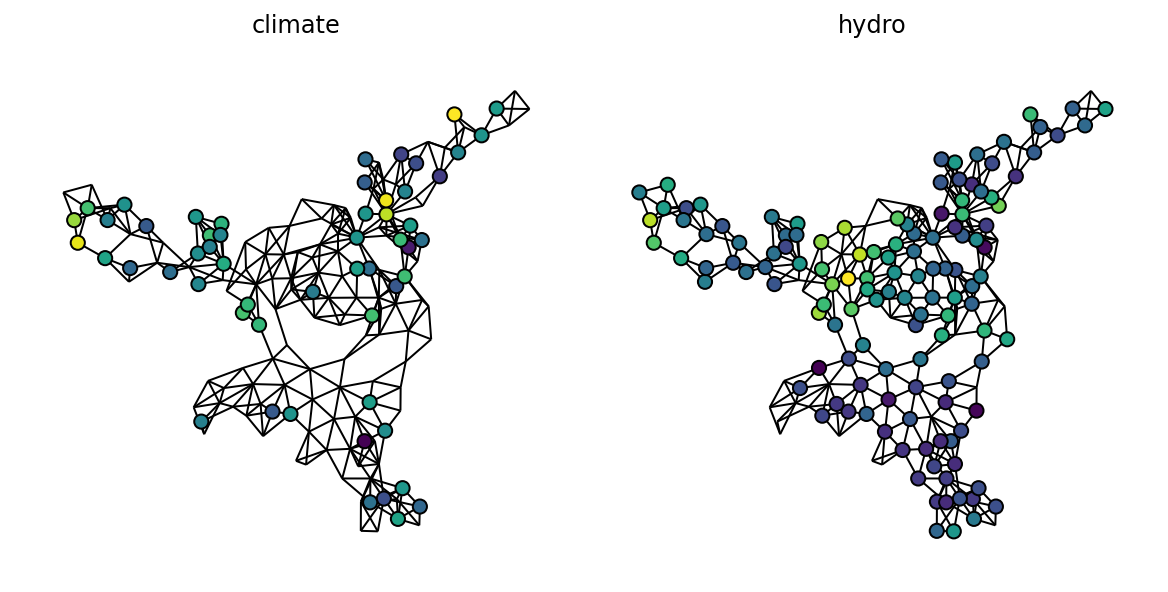

In [28]:
from networkx.drawing.nx_pydot import graphviz_layout
fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=144)
pos = graphviz_layout(G, prog='neato')
for axis, cls in zip(fig.axes, classes):
    nx.draw_networkx_edges(G, 
                           pos=pos,
                           ax=axis)
    nx.draw_networkx_nodes(G, 
                           pos=pos,
                           ax=axis,
                           node_color=[np.log(d[cls].get(n, np.nan)) for n in G.nodes],
                           node_size=50,
                           edgecolors='k'
                           )
    axis.set(title=cls)

In [29]:
#Scaling factor function
def scaling_factor_sp(A):
    """Compute the scaling factor from an adjacency matrix.
    This function uses sparse matrix computations and is most
    efficient on sparse adjacency matrices. Used in the BYM2 model.
    The scaling factor is a measure of the variance in the number of
    edges across nodes in a connected graph.
    Only works for fully connected graphs. The argument for scaling
    factors is developed by Andrea Riebler, Sigrunn H. Sørbye,
    Daniel Simpson, Havard Rue in "An intuitive Bayesian spatial
    model for disease mapping that accounts for scaling"
    https://arxiv.org/abs/1601.01180"""

    # Computes the precision matrix in sparse format
    # from an adjacency matrix.

    num_neighbors = A.sum(axis=1)
    A = sparse.csc_matrix(A)
    D = sparse.diags(num_neighbors, format="csc")
    Q = D - A

    # add a small jitter along the diagonal

    Q_perturbed = Q + sparse.diags(np.ones(Q.shape[0])) * max(Q.diagonal()) * np.sqrt(
        np.finfo(np.float64).eps
    )

    # Compute a version of the pseudo-inverse

    n = Q_perturbed.shape[0]
    b = sparse.identity(n, format="csc")
    Sigma = spsolve(Q_perturbed, b)
    A = np.ones(n)
    W = Sigma @ A.T
    Q_inv = Sigma - np.outer(W * solve(A @ W, np.ones(1)), W.T)

    # Compute the geometric mean of the diagonal on a
    # precision matrix.

    return np.exp(np.sum(np.log(np.diag(Q_inv))) / n)

In [30]:
coords = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': classes,
    'obs_idx': np.arange(df_damage.shape[0]),
    'feature': features,
    'national_feature': national_features,
    'world_feature': world_features,
    'fixed_effect': ['iso', 'year']
}

with pm.Model(coords=coords) as model4:
    X = pm.Data('X', 
                X_damage.transform(standardize).eval('square_ln_gdp_p = ln_gdp_pc ** 2'), 
                dims=['obs_idx', 'feature'])
    
    co2_idx = features.index('co2')
    not_co2_idx = [i for i in range(len(features)) if i != co2_idx]
    
    iso_idx_pt = pm.Data('iso_idx', iso_idx, dims=['obs_idx'])
    year_idx_pt = pm.Data('year_idx', year_idx, dims=['obs_idx'])
    class_idx_pt = pm.Data('class_idx', class_idx, dims=['obs_idx'])

    # Mundlak Adjustment
    beta_GX = pm.Normal('beta_GX', 0, 1, dims=['fixed_effect', 'feature'])
    
    latent_iso = pm.ZeroSumNormal('latent_iso', 3, dims=['iso', 'feature'])
    
    # The within-country variance of co2 is zero, because all countries have the same values of co2
    # So the latent effect needs to be constrained to zero (otherwise it doesn't sample)
    latent_year_national = pm.ZeroSumNormal('latent_year_national', 3, dims=['year', 'national_feature'])
    latent_year = pt.zeros((len(years), len(features)))[:, not_co2_idx].set(latent_year_national)
    
    alpha_X = pm.Normal('alpha_X', 0, 1, dims=['feature'])
    sigma_X = pm.Exponential('sigma_X', 1, dims=['feature'])
        
    mu_X = alpha_X + (beta_GX[0] * latent_iso)[iso_idx_pt] + (beta_GX[1] * latent_year)[year_idx_pt]
    X_hat = pm.Normal('X_hat', 
                      mu=mu_X, 
                      sigma=sigma_X,
                      observed=X, 
                      dims=['obs_idx', 'feature'])
    
    country_loc = pm.Normal('country_loc', 0, 1, dims=['disaster'])
    country_scale = pm.Exponential('country_scale', 1, dims=['disaster'])
    country_offset = pm.ZeroSumNormal('country_offset', 1, dims=['iso', 'disaster'])
    country_effect = pm.Deterministic('country_effect', country_loc + country_scale * country_offset,
                                      dims=['iso', 'disaster'])
    year_loc = pm.Normal('year_loc', 0, 1, dims=['disaster'])
    year_scale = pm.Gamma('year_scale', alpha=2, beta=1, dims=['disaster'])
    year_offset = pm.Normal('year_offset', 0, 1, dims=['year', 'disaster'])
    year_effect = pm.Deterministic('year_effect', 
                                   year_loc[None] + year_scale[None] * year_offset, 
                                   dims=['year', 'disaster'])
    
    beta = pm.Laplace('beta', 0, 0.5, dims=['feature', 'disaster'])
    beta_GY = pm.Normal('beta_GY', 0, 0.5, dims=['fixed_effect', 'feature', 'disaster'])    
    coef_effect = (X @ beta + 
                   (latent_iso @ beta_GY[0])[iso_idx_pt] + 
                   (latent_year @ beta_GY[1])[year_idx_pt] 
                  )
    
    # ICAR Mixin
    A = nx.adjacency_matrix(G)
    theta = pm.Normal("theta", mu = 0, sigma = 1, dims = ["iso", 'disaster'])
    phi = [pm.ICAR(f"phi_{disaster}", W = A.todense(), dims = ["iso"]) for disaster in disasters]
    phi = pm.Deterministic('phi', pt.stack(phi).T, dims=['iso', 'disaster'])
    rho = pm.Beta("rho", 0.5, 0.5, dims=['disaster'])
    mixture = pm.Deterministic("mixture", pt.sqrt(1 - rho[None]) * theta + 
                               pt.sqrt(rho[None] / scaling_factor_sp(A)) *  phi, 
                               dims = ["iso", 'disaster'])

    mu = (((country_effect + mixture)[iso_idx_pt] + year_effect[year_idx_pt]  + coef_effect) )

    sigma = pm.HalfNormal('sigma', sigma=1, dims=['disaster'])
    
    mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]
    mu = pm.Deterministic('mu', pt.concatenate(mus, axis=0), dims=['obs_idx'])
    
    p_zero = pm.Beta('p_zero', 3, 1, dims=['disaster'])
    y_hat = pm.HurdleLogNormal('y_hat',
                   mu=mu,
                   sigma=sigma[class_idx_pt],
                   psi=(1 - p_zero)[class_idx_pt],
                   observed=df_damage['Total_Damage_Adjusted'],
                   dims=['obs_idx'])

#     y_hat = pm.Mixture('y_hat', 
#                        w=[p_zero, 1 - p_zero],
#                        comp_dists=[
#                            pm.DiracDelta.dist(0.0),
#                            pm.LogNormal.dist(mu=mu,
#                                              sigma=sigma[class_idx_pt])
#                        ],
#                        observed=df_damage['Total_Damage_Adjusted'],
#                        dims=['obs_idx'])
    
# Can't prior predictive sample with ICAR priors
#     prior = pm.sample_prior_predictive().assign_coords(idx)

In [31]:
with model4:
    idata = sample_or_load(fp='idata/damage_model_f_1000.nc',
                           sample_kwargs=dict(
                               # init='advi+adapt_diag', 
#                                nuts_sampler='nutpie',
                               cores=8,
                               chains=8, 
                               draws=1000,
                               tune=1000,
                               # compile_kwargs={'mode':'NUMBA'}
#                                nuts_sampler_kwargs={'backend':'numba'}
                               ),
                           force_resample=False,
                           save_results=True,
                           compile_kwargs={'mode':'NUMBA'},
                          )
    idata = idata.assign_coords(idx)
    pm.set_data({
        'iso_idx': iso_idx_oos, 
        'year_idx': year_idx_oos, 
        'class_idx': class_idx_oos,
        'X':X_damage_full.transform(standardize).eval('square_ln_gdp_p = ln_gdp_pc ** 2')
        },
    coords={'obs_idx':np.arange(df_damage_full.shape[0])})
    idata_oos = (pm.sample_posterior_predictive(idata, predictions=True, extend_inferencedata=False,
                                               compile_kwargs={'mode':"NUMBA"})
                 .assign_coords(idx_oos))

    dmg_results['model4'] = idata

C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\tensor\rewriting\shape.py:158: UserWarning: Failed to infer_shape from Op [categorical_rv{"(p)->()"}].
Input shapes: [(TensorConstant(TensorType(int64, shape=()), data=array(0, d ... ype=int64)),), None, None, (Subtensor{i}.0, TensorConstant(TensorType(int64, shape=()), data=array(2, d ... ype=int64)))]
Exception encountered during infer_shape: <class 'KeyError'>
Exception message: Join.0
Traceback: Traceback (most recent call last):
  File "C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\tensor\rewriting\shape.py", line 134, in get_node_infer_shape
    o_shapes = shape_infer(
               ^^^^^^^^^^^^
  File "C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\compile\builders.py", line 825, in infer_shape
    out_shapes = infer_shape(self.inner_outputs, self.inner_inputs, shapes)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Output()

az.plot_trace(idata, var_names=['country_loc', 'country_scale', 'p_zero', 'rho']);

fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['country_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['year_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['beta'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=12)
    axis.set_title(disaster.title() + " Disasters, Feature Betas")

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['beta_GY'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Mundlak Adjustment")

ppc_plot('LAO', classes, idata=idata, predictions=idata_oos, hdi_lim=0.9)

damage_plot('LAO', idata_oos, df_damage, group='predictions', cls='climate')

damage_plot('LAO', idata_oos, df_damage, group='predictions')

In [32]:
with pm.do(model4, {'rho':[1, 1]}):
    pm.set_data({
        'iso_idx': iso_idx, 
        'year_idx': year_idx, 
        'class_idx': class_idx,
        'X':X_damage.transform(standardize).eval('square_ln_gdp_p = ln_gdp_pc ** 2')
        },
    coords={'obs_idx':np.arange(df_damage.shape[0])})

    rho_1_post = pm.sample_posterior_predictive(idata, var_names=['mixture'])

Sampling: []


Output()

In [33]:
iso_mean = (rho_1_post.posterior_predictive
                .mixture
                .mean(dim=['chain', 'draw'])
                .to_dataframe()
                .loc[:, 'mixture']
                .unstack('disaster'))

d = iso_mean.to_dict()

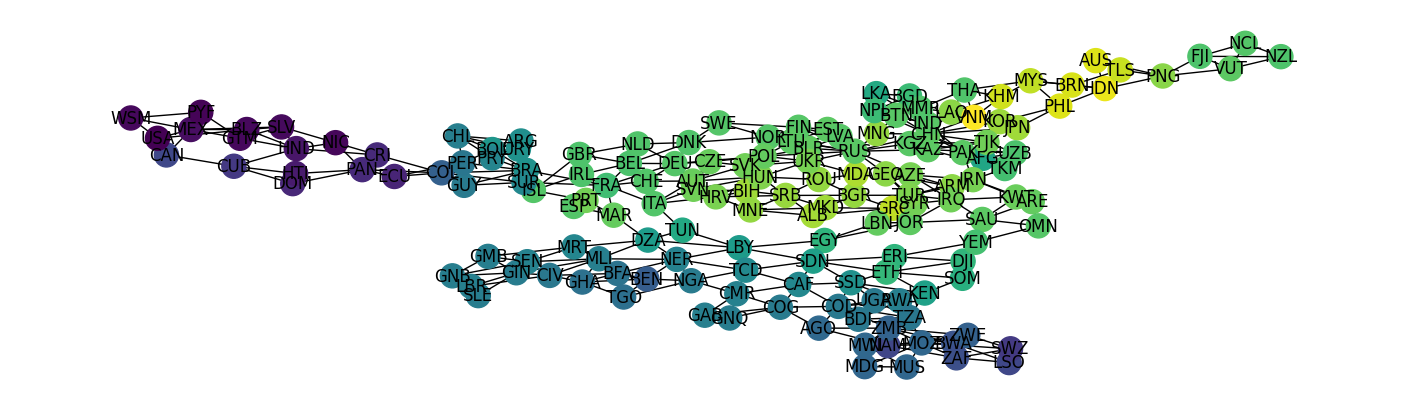

In [34]:
from networkx.drawing.nx_pydot import graphviz_layout
pos = graphviz_layout(G, prog='neato')
nx.draw_networkx(G, pos=pos, node_color=[d['climate'].get(n) for n in G.nodes])

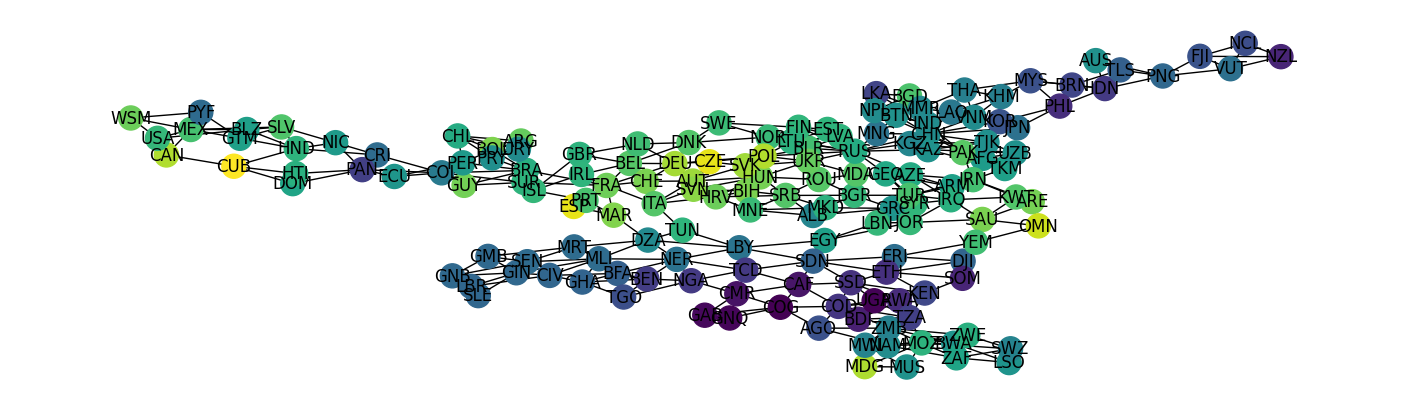

In [35]:
nx.draw_networkx(G, pos=pos, node_color=[d['hydro'].get(n) for n in G.nodes])

In [36]:
world_pos = {iso: (v['x'], v['y']) for iso, v in (world.centroid
                 .apply(lambda x: pd.Series({'x':x.x, 'y':x.y}))
                 .T
                 .to_dict()).items()}

C:\Users\camil\AppData\Local\Temp\ipykernel_22832\569447385.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_pos = {iso: (v['x'], v['y']) for iso, v in (world.centroid


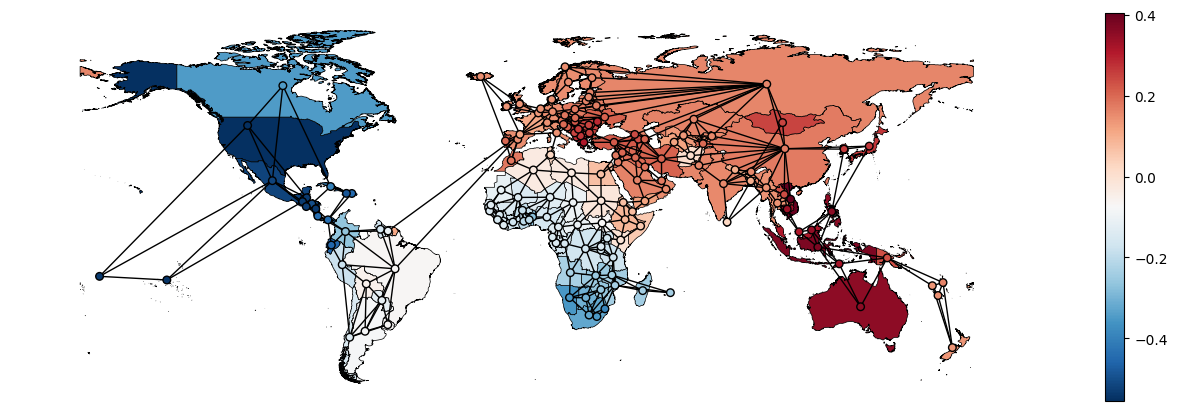

In [37]:
fig, ax = plt.subplots()
world.join(iso_mean).plot('climate', legend=True, cmap='RdBu_r', edgecolor='k', lw=0.5, ax=ax)
nx.draw_networkx_nodes(G, 
                 pos=world_pos, 
                 node_color=[d['climate'].get(n) for n in G.nodes], 
                 edgecolors='k',
                 node_size=30,
                 cmap='RdBu_r')
nx.draw_networkx_edges(G, 
                 pos=world_pos, 
                 edge_color='k')

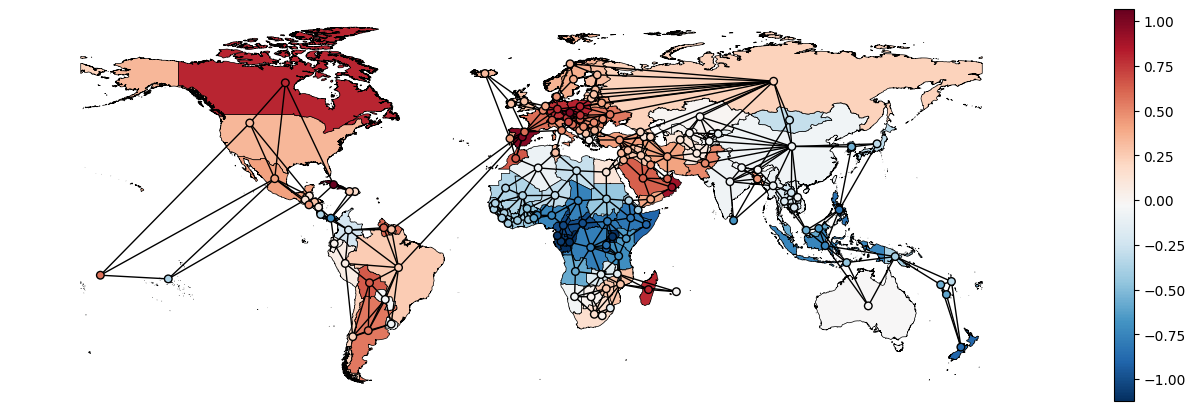

In [38]:
fig, ax = plt.subplots()
world.join(iso_mean).plot('hydro', legend=True, cmap='RdBu_r', edgecolor='k', lw=0.5, ax=ax)
nx.draw_networkx_nodes(G, 
                 pos=world_pos, 
                 node_color=[d['hydro'].get(n) for n in G.nodes], 
                 edgecolors='k',
                 node_size=30,
                 cmap='RdBu_r')
nx.draw_networkx_edges(G, 
                 pos=world_pos, 
                 edge_color='k')


# No Year FE

In [39]:
# Adjusting damage data
# Importing cpi data
import pandas as pd
import pandas_datareader.data as pdr
import datetime

# Define the CPI series code for the US
cpi_series_code = 'CPIAUCNS'

# Define the date range
start_date = datetime.datetime(1913, 1, 1)  # CPI data starts from 1913
end_date = datetime.datetime(2025, 12, 31)  # Assuming we want data up to 2025

# Fetch CPI data from FRED
cpi_data = pdr.get_data_fred(cpi_series_code, start_date, end_date)

# Display the fetched data
cpi_2015 = cpi_data.loc['2015-12-01']['CPIAUCNS']
cpi_2025 = cpi_data.loc['2025-01-01']['CPIAUCNS']


In [40]:
coords = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': classes,
    'obs_idx': np.arange(df_damage.shape[0]),
    'feature': features,
}

with pm.Model(coords=coords) as model5:
    X = pm.Data('X', 
                X_damage.transform(standardize).eval('square_ln_gdp_p = ln_gdp_pc ** 2'), 
                dims=['obs_idx', 'feature'])
        
    iso_idx_pt = pm.Data('iso_idx', iso_idx, dims=['obs_idx'])
    class_idx_pt = pm.Data('class_idx', class_idx, dims=['obs_idx'])

    # Mundlak Adjustment
    beta_GX = pm.Normal('beta_GX', 0, 1, dims=['feature'])
    latent_iso = pm.ZeroSumNormal('latent_iso', 3, dims=['iso', 'feature'])
    
    alpha_X = pm.Normal('alpha_X', 0, 1, dims=['feature'])
    sigma_X = pm.Exponential('sigma_X', 1, dims=['feature'])
        
    mu_X = alpha_X + (beta_GX[0] * latent_iso)[iso_idx_pt]
    X_hat = pm.Normal('X_hat', 
                      mu=mu_X, 
                      sigma=sigma_X,
                      observed=X, 
                      dims=['obs_idx', 'feature'])
    
    country_loc = pm.Normal('country_loc', 0, 1, dims=['disaster'])
    country_scale = pm.Exponential('country_scale', 1, dims=['disaster'])
    country_offset = pm.ZeroSumNormal('country_offset', 1, dims=['iso', 'disaster'])
    country_effect = pm.Deterministic('country_effect', country_loc + country_scale * country_offset,
                                      dims=['iso', 'disaster'])
        
    beta = pm.Laplace('beta', 0, 0.5, dims=['feature', 'disaster'])
    beta_GY = pm.Normal('beta_GY', 0, 0.5, dims=['feature', 'disaster'])    
    coef_effect = X @ beta + (latent_iso @ beta_GY)[iso_idx_pt]
    
    # ICAR Mixin
    A = nx.adjacency_matrix(G)
    theta = pm.Normal("theta", mu = 0, sigma = 1, dims = ["iso", 'disaster'])
    phi = [pm.ICAR(f"phi_{disaster}", W = A.todense(), dims = ["iso"]) for disaster in disasters]
    phi = pm.Deterministic('phi', pt.stack(phi).T, dims=['iso', 'disaster'])
    rho = pm.Beta("rho", 0.5, 0.5, dims=['disaster'])
    mixture = pm.Deterministic("mixture", pt.sqrt(1 - rho[None]) * theta + 
                               pt.sqrt(rho[None] / scaling_factor_sp(A)) *  phi, 
                               dims = ["iso", 'disaster'])

    mu = ((country_effect + mixture)[iso_idx_pt] + coef_effect)  * (cpi_2025 / cpi_2015)

    sigma = pm.HalfNormal('sigma', sigma=1, dims=['disaster'])
    
    mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]
    mu = pm.Deterministic('mu', pt.concatenate(mus, axis=0), dims=['obs_idx'])
    
    p_zero = pm.Beta('p_zero', 3, 1, dims=['disaster'])
    y_hat = pm.HurdleLogNormal('y_hat',
                   mu=mu,
                   sigma=sigma[class_idx_pt],
                   psi=(1 - p_zero)[class_idx_pt],
                   observed=df_damage['Total_Damage_Adjusted'] * (cpi_2025 / cpi_2015),
                   dims=['obs_idx'])

In [41]:
with model5:
    idata = sample_or_load(fp='idata/dmg_model_5_2025_usd_1000.nc',
                           sample_kwargs=dict(
                               # init='advi+adapt_diag', 
#                                nuts_sampler='nutpie',
                               cores=8,
                               chains=8, 
                               draws=1000,
                               tune=1000,
                               # compile_kwargs={'mode':'NUMBA'}
#                                nuts_sampler_kwargs={'backend':'numba'}
                               ),
                           force_resample=False,
                           save_results=True,
                           compile_kwargs={'mode':'NUMBA'},
                          )
    idata = idata.assign_coords(idx)
    pm.set_data({
        'iso_idx': iso_idx_oos, 
        'class_idx': class_idx_oos,
        'X':X_damage_full.transform(standardize).eval('square_ln_gdp_p = ln_gdp_pc ** 2')
        },
    coords={'obs_idx':np.arange(df_damage_full.shape[0])})
    idata_oos = (pm.sample_posterior_predictive(idata, predictions=True, extend_inferencedata=False,
                                               compile_kwargs={'mode':"NUMBA"})
                 .assign_coords(idx_oos))

    dmg_results['model5'] = idata

C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\tensor\rewriting\shape.py:158: UserWarning: Failed to infer_shape from Op [categorical_rv{"(p)->()"}].
Input shapes: [(TensorConstant(TensorType(int64, shape=()), data=array(0, d ... ype=int64)),), None, None, (Subtensor{i}.0, TensorConstant(TensorType(int64, shape=()), data=array(2, d ... ype=int64)))]
Exception encountered during infer_shape: <class 'KeyError'>
Exception message: Join.0
Traceback: Traceback (most recent call last):
  File "C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\tensor\rewriting\shape.py", line 134, in get_node_infer_shape
    o_shapes = shape_infer(
               ^^^^^^^^^^^^
  File "C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\compile\builders.py", line 825, in infer_shape
    out_shapes = infer_shape(self.inner_outputs, self.inner_inputs, shapes)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Output()

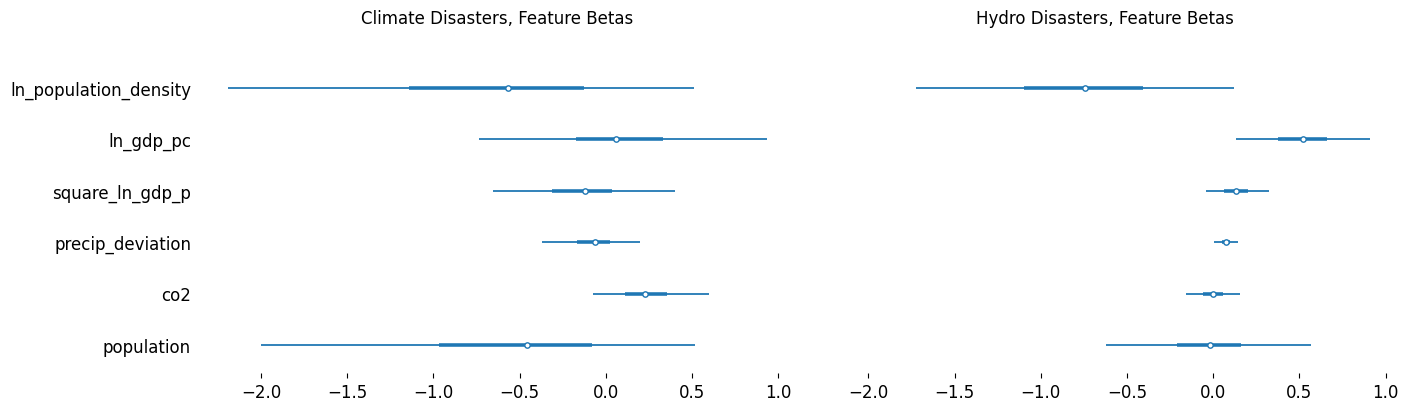

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['beta'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=12)
    axis.set_title(disaster.title() + " Disasters, Feature Betas")

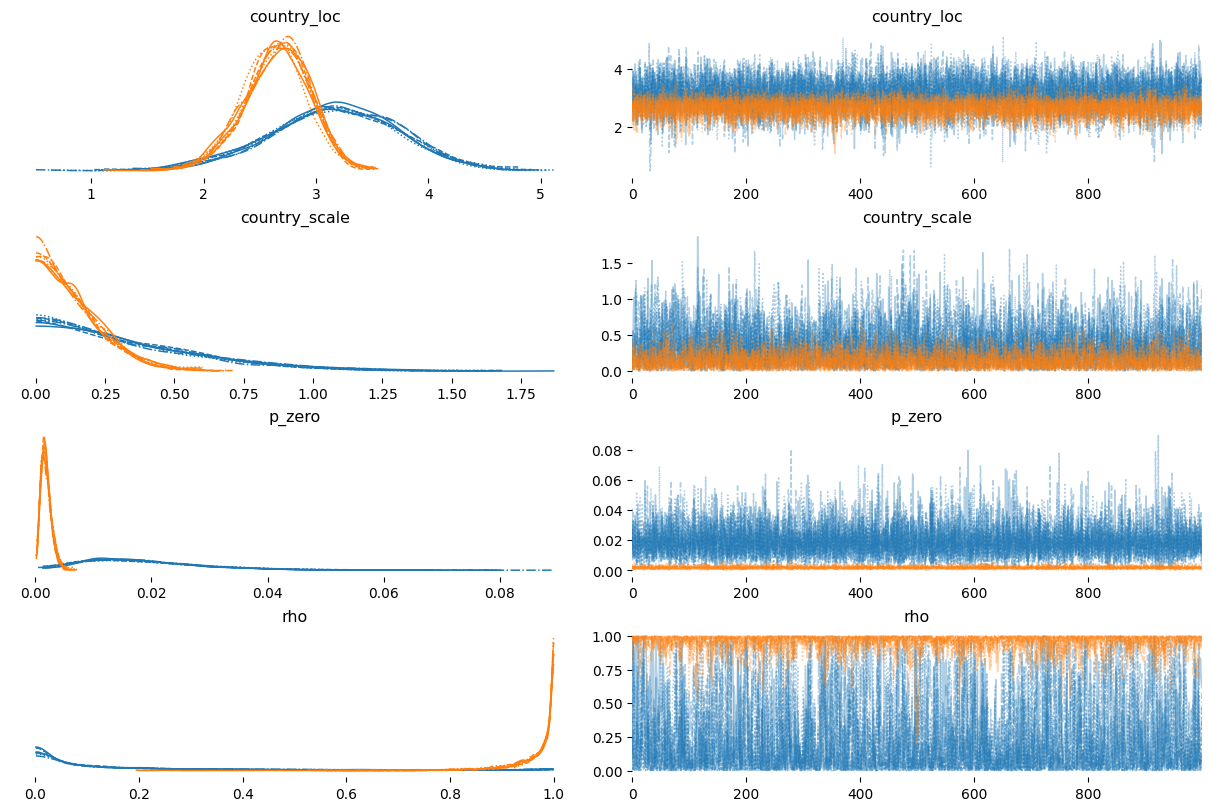

In [43]:
az.plot_trace(idata, var_names=['country_loc', 'country_scale', 'p_zero', 'rho']);

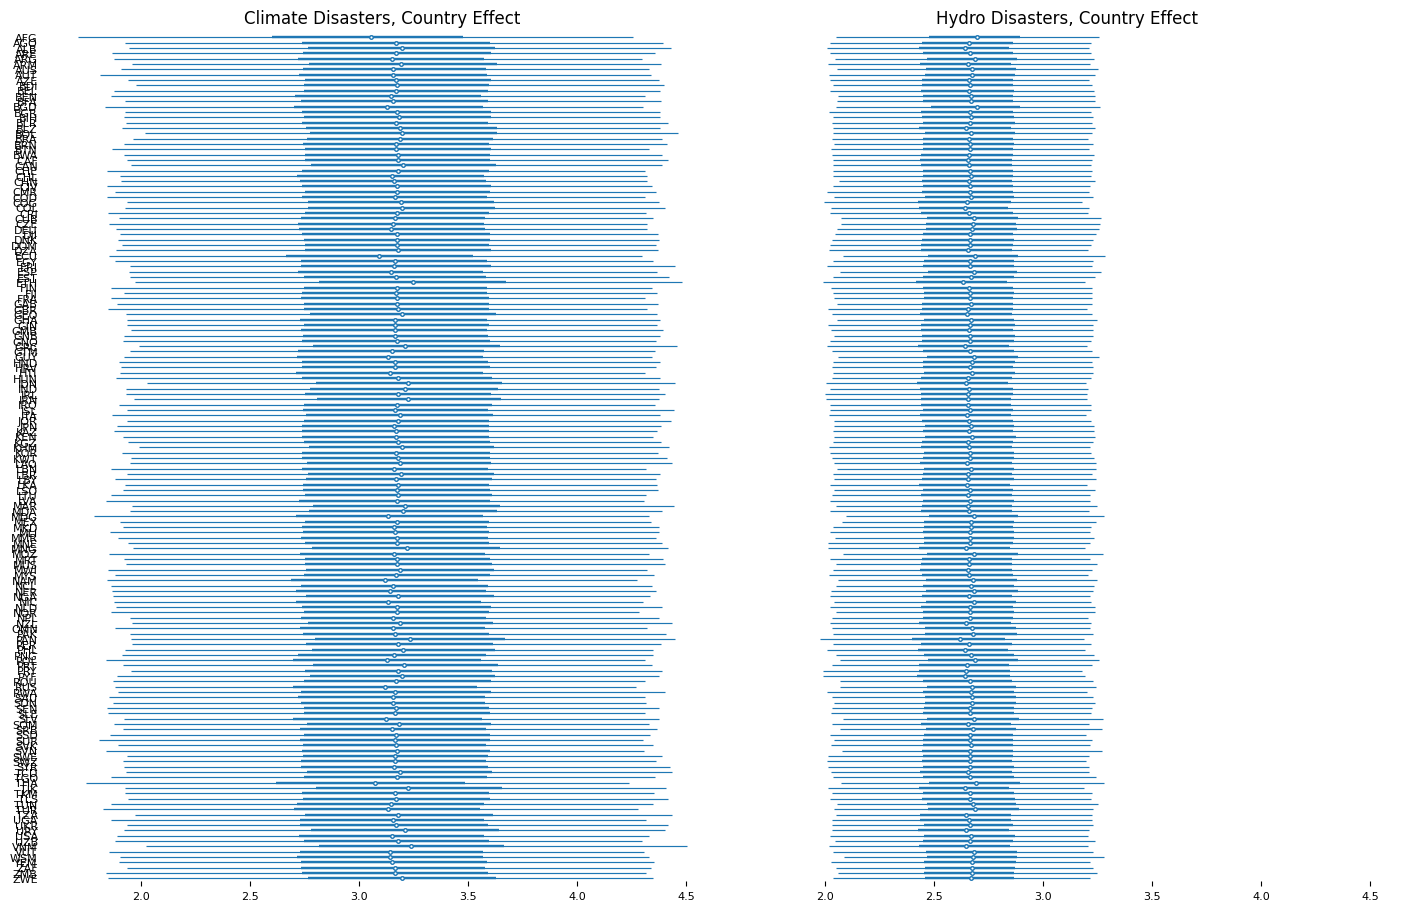

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['country_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

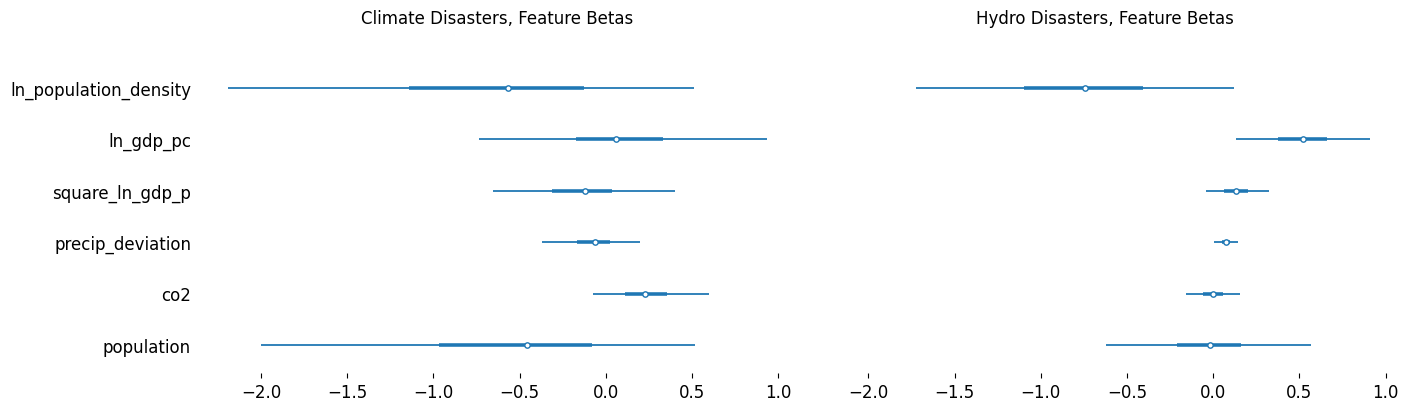

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['beta'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=12)
    axis.set_title(disaster.title() + " Disasters, Feature Betas")

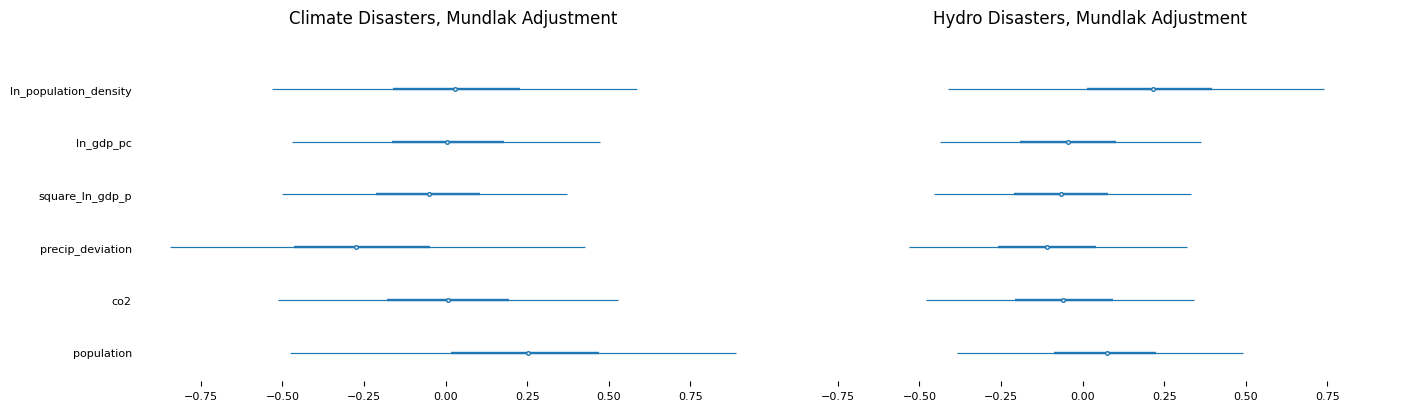

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, 
                   var_names=['beta_GY'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Mundlak Adjustment")

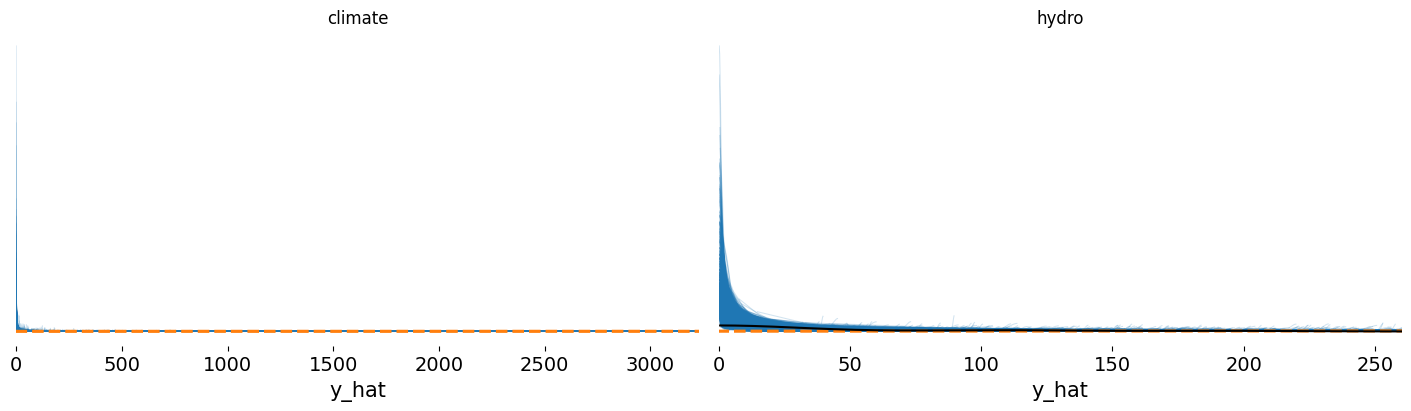

In [47]:
ppc_plot('LAO', classes, idata=idata, predictions=idata_oos, hdi_lim=0.9)

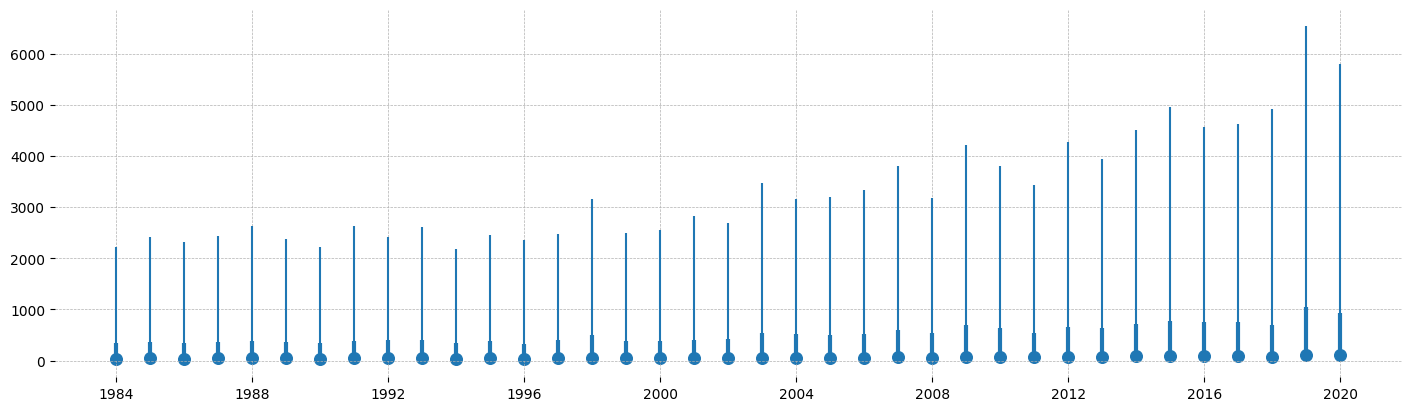

In [48]:
damage_plot('LAO', idata_oos, df_damage, group='predictions', cls='climate')

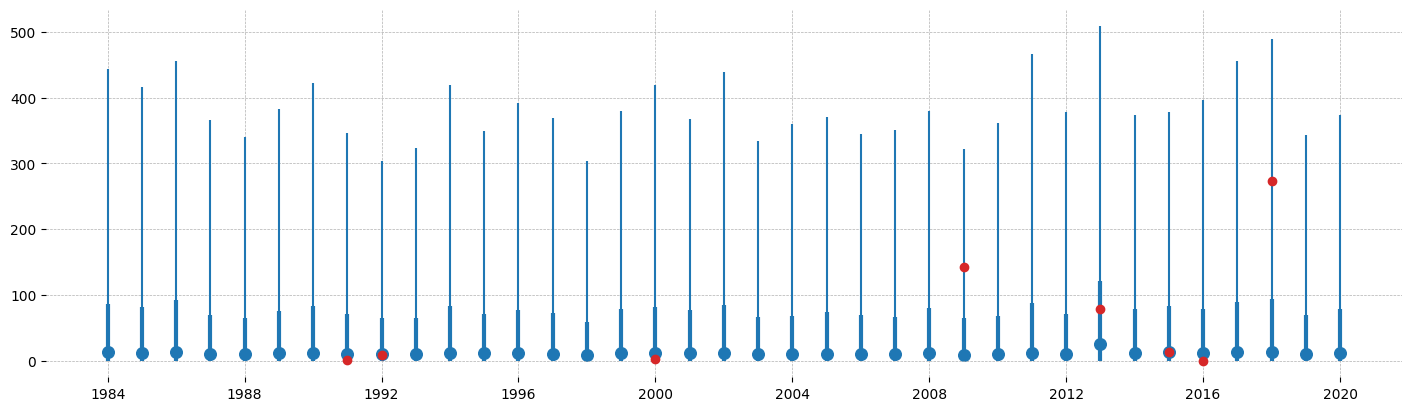

In [49]:
damage_plot('LAO', idata_oos, df_damage, group='predictions')

In [50]:
with pm.do(model4, {'rho':[1, 1]}):
    pm.set_data({
        'iso_idx': iso_idx, 
        'year_idx': year_idx, 
        'class_idx': class_idx,
        'X':X_damage.transform(standardize).eval('square_ln_gdp_p = ln_gdp_pc ** 2')
        },
    coords={'obs_idx':np.arange(df_damage.shape[0])})

    rho_1_post = pm.sample_posterior_predictive(idata, var_names=['mixture'])

Sampling: []


Output()

In [51]:
iso_mean = (rho_1_post.posterior_predictive
                .mixture
                .mean(dim=['chain', 'draw'])
                .to_dataframe()
                .loc[:, 'mixture']
                .unstack('disaster'))

d = iso_mean.to_dict()

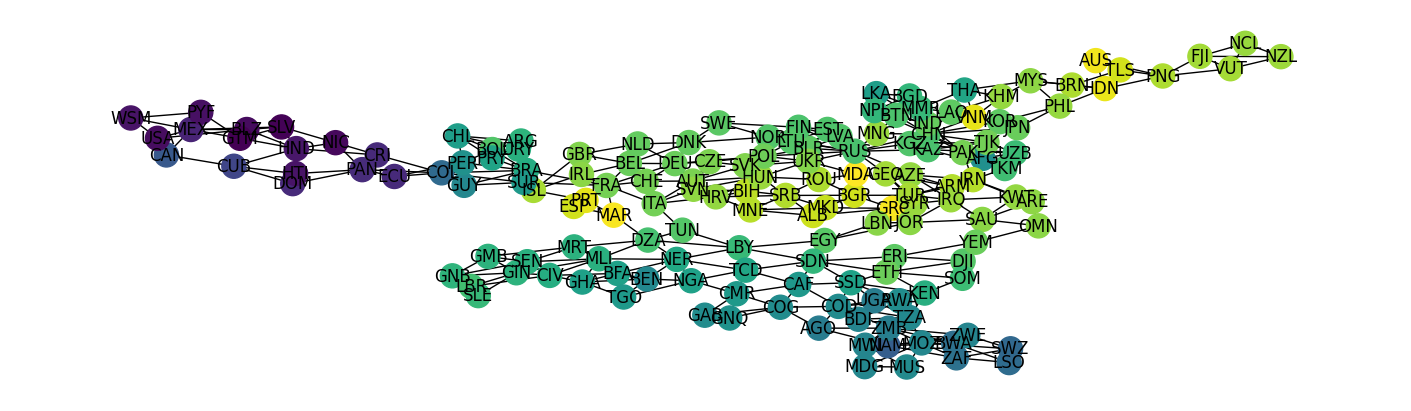

In [52]:
from networkx.drawing.nx_pydot import graphviz_layout
pos = graphviz_layout(G, prog='neato')
nx.draw_networkx(G, pos=pos, node_color=[d['climate'].get(n) for n in G.nodes])

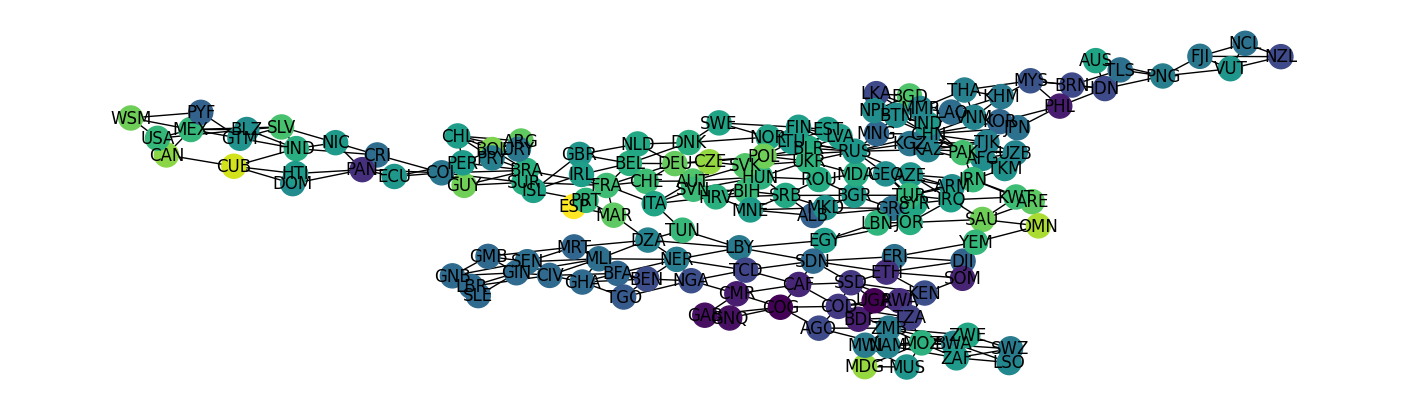

In [53]:
nx.draw_networkx(G, pos=pos, node_color=[d['hydro'].get(n) for n in G.nodes])

In [54]:
world_pos = {iso: (v['x'], v['y']) for iso, v in (world.centroid
                 .apply(lambda x: pd.Series({'x':x.x, 'y':x.y}))
                 .T
                 .to_dict()).items()}

C:\Users\camil\AppData\Local\Temp\ipykernel_22832\569447385.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_pos = {iso: (v['x'], v['y']) for iso, v in (world.centroid


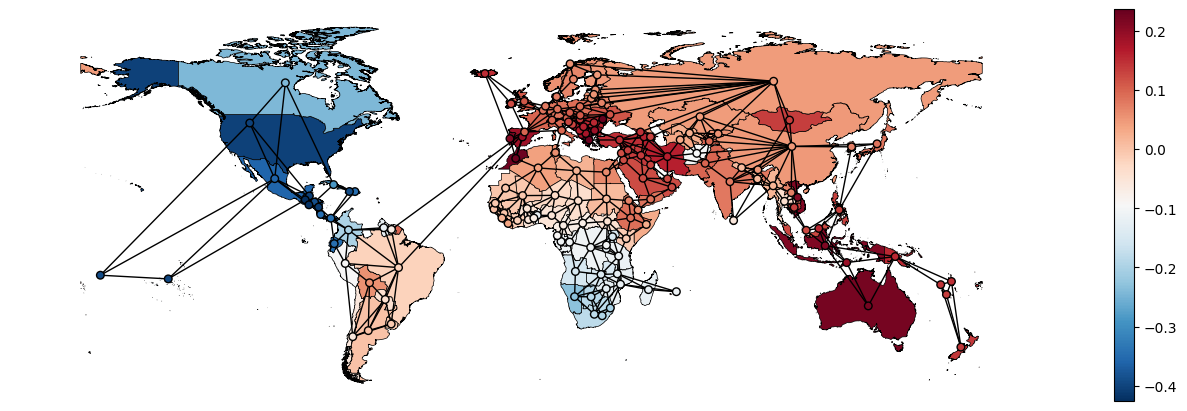

In [55]:
fig, ax = plt.subplots()
world.join(iso_mean).plot('climate', legend=True, cmap='RdBu_r', edgecolor='k', lw=0.5, ax=ax)
nx.draw_networkx_nodes(G, 
                 pos=world_pos, 
                 node_color=[d['climate'].get(n) for n in G.nodes], 
                 edgecolors='k',
                 node_size=30,
                 cmap='RdBu_r')
nx.draw_networkx_edges(G, 
                 pos=world_pos, 
                 edge_color='k')

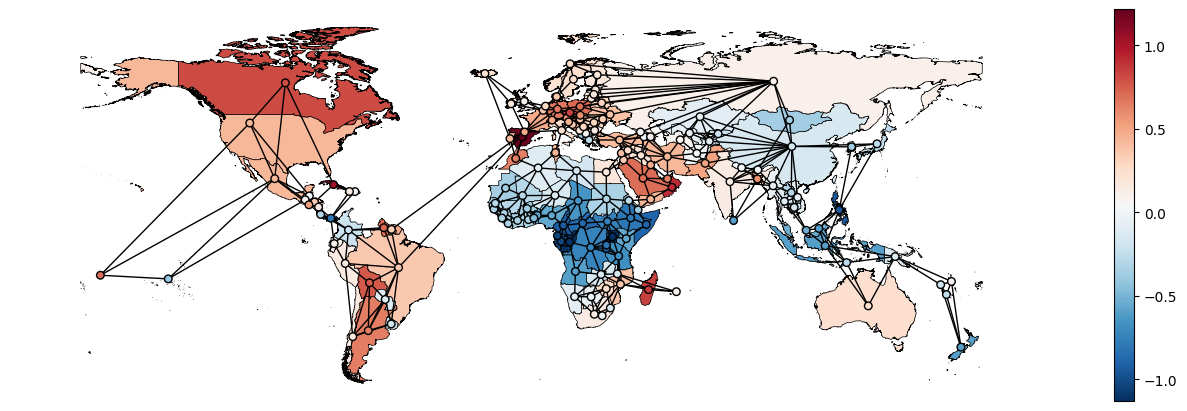

In [56]:
fig, ax = plt.subplots()
world.join(iso_mean).plot('hydro', legend=True, cmap='RdBu_r', edgecolor='k', lw=0.5, ax=ax)
nx.draw_networkx_nodes(G, 
                 pos=world_pos, 
                 node_color=[d['hydro'].get(n) for n in G.nodes], 
                 edgecolors='k',
                 node_size=30,
                 cmap='RdBu_r')
nx.draw_networkx_edges(G, 
                 pos=world_pos, 
                 edge_color='k')


In [57]:
az.compare(dmg_results, var_name='y_hat')

C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
C:\Users\camil\miniforge3\en

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model3,0,147.715778,108.892811,0.000000,1.000000e+00,119.963171,0.000000,True,log
model4,1,-15405.540569,121.009660,15553.256347,3.589271e-14,119.951234,8.300088,True,log
model5,2,-16092.557466,98.726217,16240.273243,3.619327e-14,119.742687,12.276384,True,log
